In [9]:
# ── CELL 1: Imports & config ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib

RANDOM_STATE = 42
TARGET       = "fire_risk_class"
RISK_LABELS  = ["NO_FIRE", "ACTIVE", "SIGNIFICANT"]
OUT_DIR      = Path("outputs/model_comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Imports loaded")

✓ Imports loaded


In [10]:
# ── CELL 2: Load data & split ─────────────────────────────────────
df = pd.read_parquet("../data/integrated/algeria_wildfire_dataset_features.parquet")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

FEATURES = [
    "temp_c", "rh", "precip_mm", "soil_moisture",
    "temp_mean_7d",
    "rh_mean_7d", "rh_min_7d",
    "rain_7d", "rain_14d", "rain_30d",
    "days_since_rain", "hot_days_streak",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
    "FWI_mean_7d", "FWI_max_7d", "FWI_max_14d",
    "NDVI", "NDWI", "NBR",
    "elevation_mean_m", "slope_mean_deg",
    "pop_density_mean", "road_distance_mean_km", "ignition_pressure",
    "fires_prev_year_month",
    "day_of_year", "month_sin",
    "NBR_FWI", "heat_drought",
]
FEATURES = [f for f in FEATURES if f in df.columns]

# Year-based split — never random for temporal data
train_df = df[df["year"] <= 2022]
val_df   = df[df["year"] == 2023]
test_df  = df[df["year"] >= 2024]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

print(f"Features  : {len(FEATURES)}")
print(f"Train     : {X_train.shape}  fire={( y_train>0).sum():,} ({100*(y_train>0).mean():.1f}%)")
print(f"Val       : {X_val.shape}  fire={(y_val>0).sum():,} ({100*(y_val>0).mean():.1f}%)")
print(f"Test      : {X_test.shape}  fire={(y_test>0).sum():,} ({100*(y_test>0).mean():.1f}%)")
print(f"\nClass distribution (train):")
print(y_train.value_counts().sort_index().to_string())

Features  : 34
Train     : (69168, 34)  fire=21,918 (31.7%)
Val       : (8832, 34)  fire=2,477 (28.0%)
Test      : (17664, 34)  fire=8,980 (50.8%)

Class distribution (train):
fire_risk_class
0    47250
1    15719
2     6199


In [11]:
# ── CELL 3: Shared evaluation function ───────────────────────────
def evaluate(name, y_true, y_pred, y_proba, split="val", train_time=0):
    return {
        "model":        name,
        "split":        split,
        "macro_f1":     round(f1_score(y_true, y_pred, average="macro"),    4),
        "weighted_f1":  round(f1_score(y_true, y_pred, average="weighted"), 4),
        "macro_auc":    round(roc_auc_score(y_true, y_proba,
                              multi_class="ovr", average="macro"),           4),
        "accuracy":     round(accuracy_score(y_true, y_pred),               4),
        "f1_no_fire":   round(f1_score(y_true, y_pred, average=None)[0],    4),
        "f1_active":    round(f1_score(y_true, y_pred, average=None)[1],    4),
        "f1_significant":round(f1_score(y_true, y_pred, average=None)[2],   4),
        "train_time_s": round(train_time, 1),
    }

results = []
models  = {}   # store best trained model per name
print("✓ Evaluation function ready")

✓ Evaluation function ready


In [13]:
# ── CELL 4: MODEL 1 — Logistic Regression (linear baseline) ───────
print("=" * 55)
print("MODEL 1: Logistic Regression (linear baseline)")
print("=" * 55)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

t0 = time.time()
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    C=0.1,
)
lr.fit(X_train_sc, y_train)
train_time = time.time() - t0

val_pred  = lr.predict(X_val_sc)
val_proba = lr.predict_proba(X_val_sc)
test_pred  = lr.predict(X_test_sc)
test_proba = lr.predict_proba(X_test_sc)

results.append(evaluate("LogisticRegression", y_val,  val_pred,  val_proba,  "val",  train_time))
results.append(evaluate("LogisticRegression", y_test, test_pred, test_proba, "test", train_time))
models["LogisticRegression"] = lr

print(f"Train time: {train_time:.1f}s")
print("\nValidation:")
print(classification_report(y_val, val_pred, target_names=RISK_LABELS))

MODEL 1: Logistic Regression (linear baseline)
Train time: 6.9s

Validation:
              precision    recall  f1-score   support

     NO_FIRE       0.83      0.61      0.70      6355
      ACTIVE       0.32      0.33      0.32      1783
 SIGNIFICANT       0.21      0.70      0.33       694

    accuracy                           0.56      8832
   macro avg       0.45      0.55      0.45      8832
weighted avg       0.68      0.56      0.60      8832



In [12]:
# ── CELL 5: MODEL 2 — Random Forest (Optuna 30 trials) ───────────
print("=" * 55)
print("MODEL 2: Random Forest")
print("=" * 55)

def rf_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 5, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features":     trial.suggest_float("max_features", 0.3, 1.0),
        "class_weight":     "balanced",
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
    }
    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train, sample_weight=sample_weights)
    pred = rf.predict(X_val)
    return f1_score(y_val, pred, average="macro")

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest val Macro F1: {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

t0 = time.time()
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf.fit(X_train, y_train, sample_weight=sample_weights)
train_time = time.time() - t0

val_pred   = best_rf.predict(X_val)
val_proba  = best_rf.predict_proba(X_val)
test_pred  = best_rf.predict(X_test)
test_proba = best_rf.predict_proba(X_test)

results.append(evaluate("RandomForest", y_val,  val_pred,  val_proba,  "val",  train_time))
results.append(evaluate("RandomForest", y_test, test_pred, test_proba, "test", train_time))
models["RandomForest"] = best_rf

print(f"\nValidation:")
print(classification_report(y_val, val_pred, target_names=RISK_LABELS))

MODEL 2: Random Forest


  0%|          | 0/30 [00:00<?, ?it/s]


Best val Macro F1: 0.5638
Best params: {'n_estimators': 477, 'max_depth': 21, 'min_samples_leaf': 2, 'max_features': 0.550828297947078}

Validation:
              precision    recall  f1-score   support

     NO_FIRE       0.84      0.72      0.77      6355
      ACTIVE       0.35      0.50      0.41      1783
 SIGNIFICANT       0.47      0.55      0.51       694

    accuracy                           0.66      8832
   macro avg       0.55      0.59      0.56      8832
weighted avg       0.71      0.66      0.68      8832



In [14]:
# ── CELL 6: MODEL 3 — LightGBM (Optuna 100 trials) ───────────────
print("=" * 55)
print("MODEL 3: LightGBM")
print("=" * 55)

lgb_train_ds = lgb.Dataset(X_train, label=y_train,
                            weight=sample_weights, free_raw_data=False)
lgb_val_ds   = lgb.Dataset(X_val,   label=y_val,
                            reference=lgb_train_ds, free_raw_data=False)

def lgb_objective(trial):
    params = {
        "objective":         "multiclass",
        "num_class":         3,
        "metric":            "multi_logloss",
        "boosting_type":     "gbdt",
        "verbose":           -1,
        "random_state":      RANDOM_STATE,
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1":         trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
    }
    cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(9999)]
    m = lgb.train(params, lgb_train_ds, num_boost_round=2000,
                  valid_sets=[lgb_val_ds], callbacks=cb)
    pred = np.argmax(m.predict(X_val), axis=1)
    return f1_score(y_val, pred, average="macro")

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest val Macro F1: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

best_lgb_params = {
    "objective": "multiclass", "num_class": 3,
    "metric": "multi_logloss", "boosting_type": "gbdt",
    "verbose": -1, "random_state": RANDOM_STATE,
    **study_lgb.best_params
}
t0 = time.time()
best_lgb = lgb.train(
    best_lgb_params, lgb_train_ds,
    num_boost_round=2000,
    valid_sets=[lgb_val_ds],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(50)],
)
train_time = time.time() - t0

val_pred   = np.argmax(best_lgb.predict(X_val),  axis=1)
val_proba  = best_lgb.predict(X_val)
test_pred  = np.argmax(best_lgb.predict(X_test), axis=1)
test_proba = best_lgb.predict(X_test)

results.append(evaluate("LightGBM", y_val,  val_pred,  val_proba,  "val",  train_time))
results.append(evaluate("LightGBM", y_test, test_pred, test_proba, "test", train_time))
models["LightGBM"] = best_lgb

print(f"\nValidation:")
print(classification_report(y_val, val_pred, target_names=RISK_LABELS))

MODEL 3: LightGBM


  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `


Best val Macro F1: 0.5685
Best params: {'num_leaves': 214, 'max_depth': 12, 'learning_rate': 0.015478932871231981, 'min_child_samples': 10, 'feature_fraction': 0.5400640976246419, 'bagging_fraction': 0.9493613320662507, 'bagging_freq': 1, 'lambda_l1': 0.05449096800866978, 'lambda_l2': 0.37049885477495187}
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.879235
[100]	valid_0's multi_logloss: 0.823051
[150]	valid_0's multi_logloss: 0.805709
[200]	valid_0's multi_logloss: 0.799596
[250]	valid_0's multi_logloss: 0.793719
[300]	valid_0's multi_logloss: 0.790796
[350]	valid_0's multi_logloss: 0.787712
[400]	valid_0's multi_logloss: 0.783977
[450]	valid_0's multi_logloss: 0.781384
[500]	valid_0's multi_logloss: 0.777956
[550]	valid_0's multi_logloss: 0.775599
[600]	valid_0's multi_logloss: 0.773003
[650]	valid_0's multi_logloss: 0.770514
[700]	valid_0's multi_logloss: 0.768494
[750]	valid_0's multi_logloss: 0.766147
[800]	valid_0's multi_logloss: 0

In [15]:
# ── CELL 7: MODEL 4 — XGBoost (Optuna 100 trials) ────────────────
print("=" * 55)
print("MODEL 4: XGBoost")
print("=" * 55)

def xgb_objective(trial):
    params = {
        "objective":        "multi:softprob",
        "num_class":        3,
        "eval_metric":      "mlogloss",
        "random_state":     RANDOM_STATE,
        "verbosity":        0,
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    m = xgb.XGBClassifier(**params, early_stopping_rounds=50,
                           use_label_encoder=False)
    m.fit(X_train, y_train,
          sample_weight=sample_weights,
          eval_set=[(X_val, y_val)],
          verbose=False)
    pred = m.predict(X_val)
    return f1_score(y_val, pred, average="macro")

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest val Macro F1: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

t0 = time.time()
best_xgb = xgb.XGBClassifier(
    objective="multi:softprob", num_class=3,
    eval_metric="mlogloss", random_state=RANDOM_STATE,
    verbosity=0, early_stopping_rounds=50,
    **study_xgb.best_params
)
best_xgb.fit(X_train, y_train,
             sample_weight=sample_weights,
             eval_set=[(X_val, y_val)],
             verbose=False)
train_time = time.time() - t0

val_pred   = best_xgb.predict(X_val)
val_proba  = best_xgb.predict_proba(X_val)
test_pred  = best_xgb.predict(X_test)
test_proba = best_xgb.predict_proba(X_test)

results.append(evaluate("XGBoost", y_val,  val_pred,  val_proba,  "val",  train_time))
results.append(evaluate("XGBoost", y_test, test_pred, test_proba, "test", train_time))
models["XGBoost"] = best_xgb

print(f"\nValidation:")
print(classification_report(y_val, val_pred, target_names=RISK_LABELS))

MODEL 4: XGBoost


  0%|          | 0/100 [00:00<?, ?it/s]


Best val Macro F1: 0.5653
Best params: {'max_depth': 12, 'learning_rate': 0.012449000532868881, 'n_estimators': 979, 'gamma': 0.652610588582647, 'subsample': 0.7690852644603655, 'colsample_bytree': 0.6411510359114332, 'min_child_weight': 2, 'reg_alpha': 0.002862551332855613, 'reg_lambda': 0.002875199118708181}

Validation:
              precision    recall  f1-score   support

     NO_FIRE       0.83      0.75      0.79      6355
      ACTIVE       0.37      0.46      0.41      1783
 SIGNIFICANT       0.44      0.57      0.50       694

    accuracy                           0.68      8832
   macro avg       0.55      0.59      0.57      8832
weighted avg       0.71      0.68      0.69      8832



In [16]:
# ── CELL 8: MODEL 5 — CatBoost (Optuna 50 trials) ────────────────
print("=" * 55)
print("MODEL 5: CatBoost")
print("=" * 55)

def cat_objective(trial):
    params = {
        "loss_function":   "MultiClass",
        "classes_count":   3,
        "random_seed":     RANDOM_STATE,
        "verbose":         False,
        "depth":           trial.suggest_int("depth", 4, 10),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "iterations":      trial.suggest_int("iterations", 200, 1000),
        "l2_leaf_reg":     trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count":    trial.suggest_int("border_count", 32, 255),
    }
    m = CatBoostClassifier(**params)
    m.fit(X_train, y_train,
          sample_weight=sample_weights,
          eval_set=(X_val, y_val),
          early_stopping_rounds=50,
          verbose=False)
    pred = m.predict(X_val).flatten()
    return f1_score(y_val, pred, average="macro")

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(cat_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest val Macro F1: {study_cat.best_value:.4f}")
print(f"Best params: {study_cat.best_params}")

t0 = time.time()
best_cat = CatBoostClassifier(
    loss_function="MultiClass", classes_count=3,
    random_seed=RANDOM_STATE, verbose=False,
    early_stopping_rounds=50,
    **study_cat.best_params
)
best_cat.fit(X_train, y_train,
             sample_weight=sample_weights,
             eval_set=(X_val, y_val),
             verbose=False)
train_time = time.time() - t0

val_pred   = best_cat.predict(X_val).flatten()
val_proba  = best_cat.predict_proba(X_val)
test_pred  = best_cat.predict(X_test).flatten()
test_proba = best_cat.predict_proba(X_test)

results.append(evaluate("CatBoost", y_val,  val_pred,  val_proba,  "val",  train_time))
results.append(evaluate("CatBoost", y_test, test_pred, test_proba, "test", train_time))
models["CatBoost"] = best_cat

print(f"\nValidation:")
print(classification_report(y_val, val_pred, target_names=RISK_LABELS))

MODEL 5: CatBoost


  0%|          | 0/50 [00:00<?, ?it/s]


Best val Macro F1: 0.5642
Best params: {'depth': 10, 'learning_rate': 0.0626120301469455, 'iterations': 725, 'l2_leaf_reg': 0.008771254838973242, 'bagging_temperature': 0.8518166883973686, 'border_count': 201}

Validation:
              precision    recall  f1-score   support

     NO_FIRE       0.84      0.73      0.78      6355
      ACTIVE       0.36      0.46      0.40      1783
 SIGNIFICANT       0.44      0.60      0.51       694

    accuracy                           0.67      8832
   macro avg       0.54      0.60      0.56      8832
weighted avg       0.71      0.67      0.68      8832



In [17]:
# ── CELL 9: Comparison table ──────────────────────────────────────
results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 70)
val_results = (results_df[results_df["split"] == "val"]
               .sort_values("macro_auc", ascending=False)
               .reset_index(drop=True))
print(val_results[["model","macro_f1","weighted_f1","macro_auc",
                    "f1_no_fire","f1_active","f1_significant",
                    "train_time_s"]].to_string(index=False))

print("\n" + "=" * 70)
print("MODEL COMPARISON — TEST SET")
print("=" * 70)
test_results = (results_df[results_df["split"] == "test"]
                .sort_values("macro_auc", ascending=False)
                .reset_index(drop=True))
print(test_results[["model","macro_f1","weighted_f1","macro_auc",
                     "f1_no_fire","f1_active","f1_significant",
                     "train_time_s"]].to_string(index=False))

results_df.to_csv(OUT_DIR / "comparison_results.csv", index=False)
print(f"\n✓ Saved → {OUT_DIR / 'comparison_results.csv'}")

MODEL COMPARISON — VALIDATION SET
             model  macro_f1  weighted_f1  macro_auc  f1_no_fire  f1_active  f1_significant  train_time_s
          CatBoost    0.5642       0.6837     0.7608      0.7816     0.4032          0.5076          85.7
           XGBoost    0.5653       0.6880     0.7540      0.7867     0.4094          0.4997          90.0
          LightGBM    0.5685       0.6904     0.7527      0.7925     0.3927          0.5204         176.6
      RandomForest    0.5638       0.6787     0.7454      0.7731     0.4075          0.5109          67.1
LogisticRegression    0.4519       0.5981     0.7157      0.7046     0.3241          0.3271           6.9

MODEL COMPARISON — TEST SET
             model  macro_f1  weighted_f1  macro_auc  f1_no_fire  f1_active  f1_significant  train_time_s
      RandomForest    0.5566       0.5918     0.7579      0.7277     0.4437          0.4983          67.1
          LightGBM    0.5178       0.5613     0.7476      0.7233     0.3887          0.44

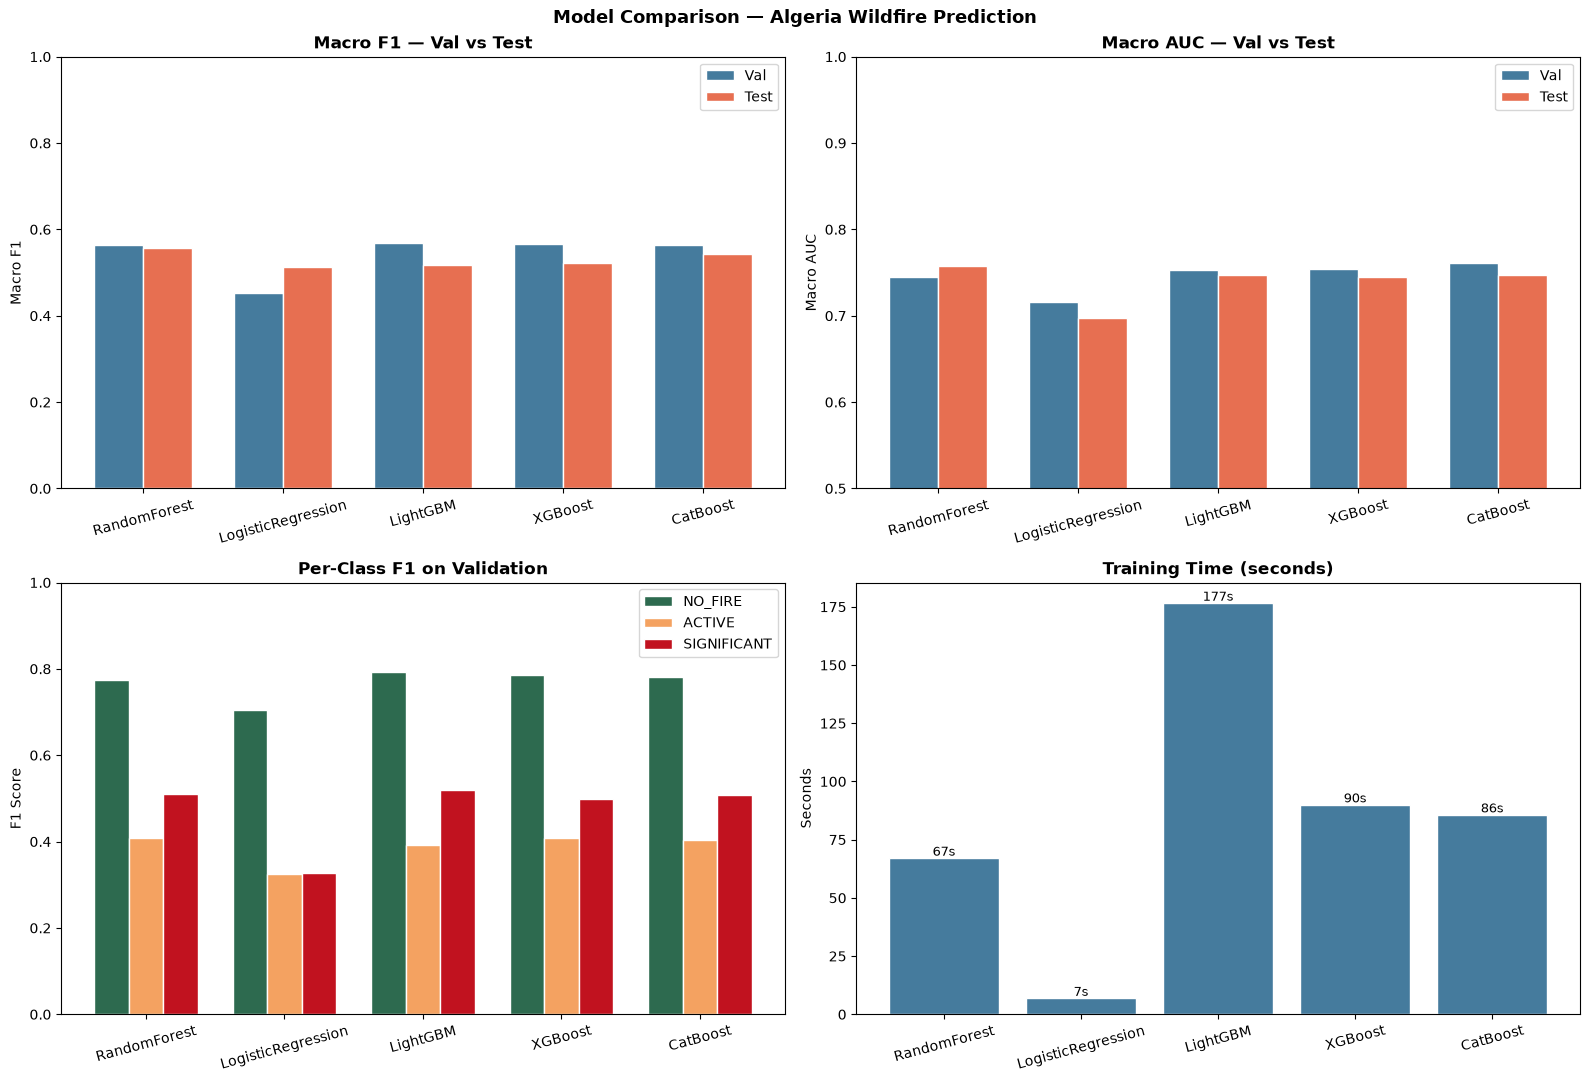

In [18]:
# ── CELL 10: Comparison plots ─────────────────────────────────────
val_r  = results_df[results_df["split"] == "val"].set_index("model")
test_r = results_df[results_df["split"] == "test"].set_index("model")
model_names = val_r.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Macro F1 val vs test
x = np.arange(len(model_names))
w = 0.35
axes[0,0].bar(x - w/2, val_r["macro_f1"],  w, label="Val",  color="#457b9d", edgecolor="white")
axes[0,0].bar(x + w/2, test_r.loc[model_names,"macro_f1"], w, label="Test", color="#e76f51", edgecolor="white")
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(model_names, rotation=15)
axes[0,0].set_title("Macro F1 — Val vs Test", fontweight="bold")
axes[0,0].set_ylabel("Macro F1"); axes[0,0].legend()
axes[0,0].set_ylim(0, 1)

# Macro AUC val vs test
axes[0,1].bar(x - w/2, val_r["macro_auc"],  w, label="Val",  color="#457b9d", edgecolor="white")
axes[0,1].bar(x + w/2, test_r.loc[model_names,"macro_auc"], w, label="Test", color="#e76f51", edgecolor="white")
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(model_names, rotation=15)
axes[0,1].set_title("Macro AUC — Val vs Test", fontweight="bold")
axes[0,1].set_ylabel("Macro AUC"); axes[0,1].legend()
axes[0,1].set_ylim(0.5, 1)

# Per-class F1 on val
metrics = ["f1_no_fire", "f1_active", "f1_significant"]
class_colors = ["#2d6a4f", "#f4a261", "#c1121f"]
x2 = np.arange(len(model_names))
w2 = 0.25
for i, (m, c, lbl) in enumerate(zip(metrics, class_colors, RISK_LABELS)):
    axes[1,0].bar(x2 + (i-1)*w2, val_r[m], w2,
                  label=lbl, color=c, edgecolor="white")
axes[1,0].set_xticks(x2); axes[1,0].set_xticklabels(model_names, rotation=15)
axes[1,0].set_title("Per-Class F1 on Validation", fontweight="bold")
axes[1,0].set_ylabel("F1 Score"); axes[1,0].legend()
axes[1,0].set_ylim(0, 1)

# Training time
axes[1,1].bar(model_names, val_r["train_time_s"],
              color="#457b9d", edgecolor="white")
axes[1,1].set_title("Training Time (seconds)", fontweight="bold")
axes[1,1].set_ylabel("Seconds")
axes[1,1].set_xticklabels(model_names, rotation=15)
for bar, val in zip(axes[1,1].patches, val_r["train_time_s"]):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+1,
                   f"{val:.0f}s", ha="center", fontsize=9)

plt.suptitle("Model Comparison — Algeria Wildfire Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison.png", dpi=150)
plt.show()

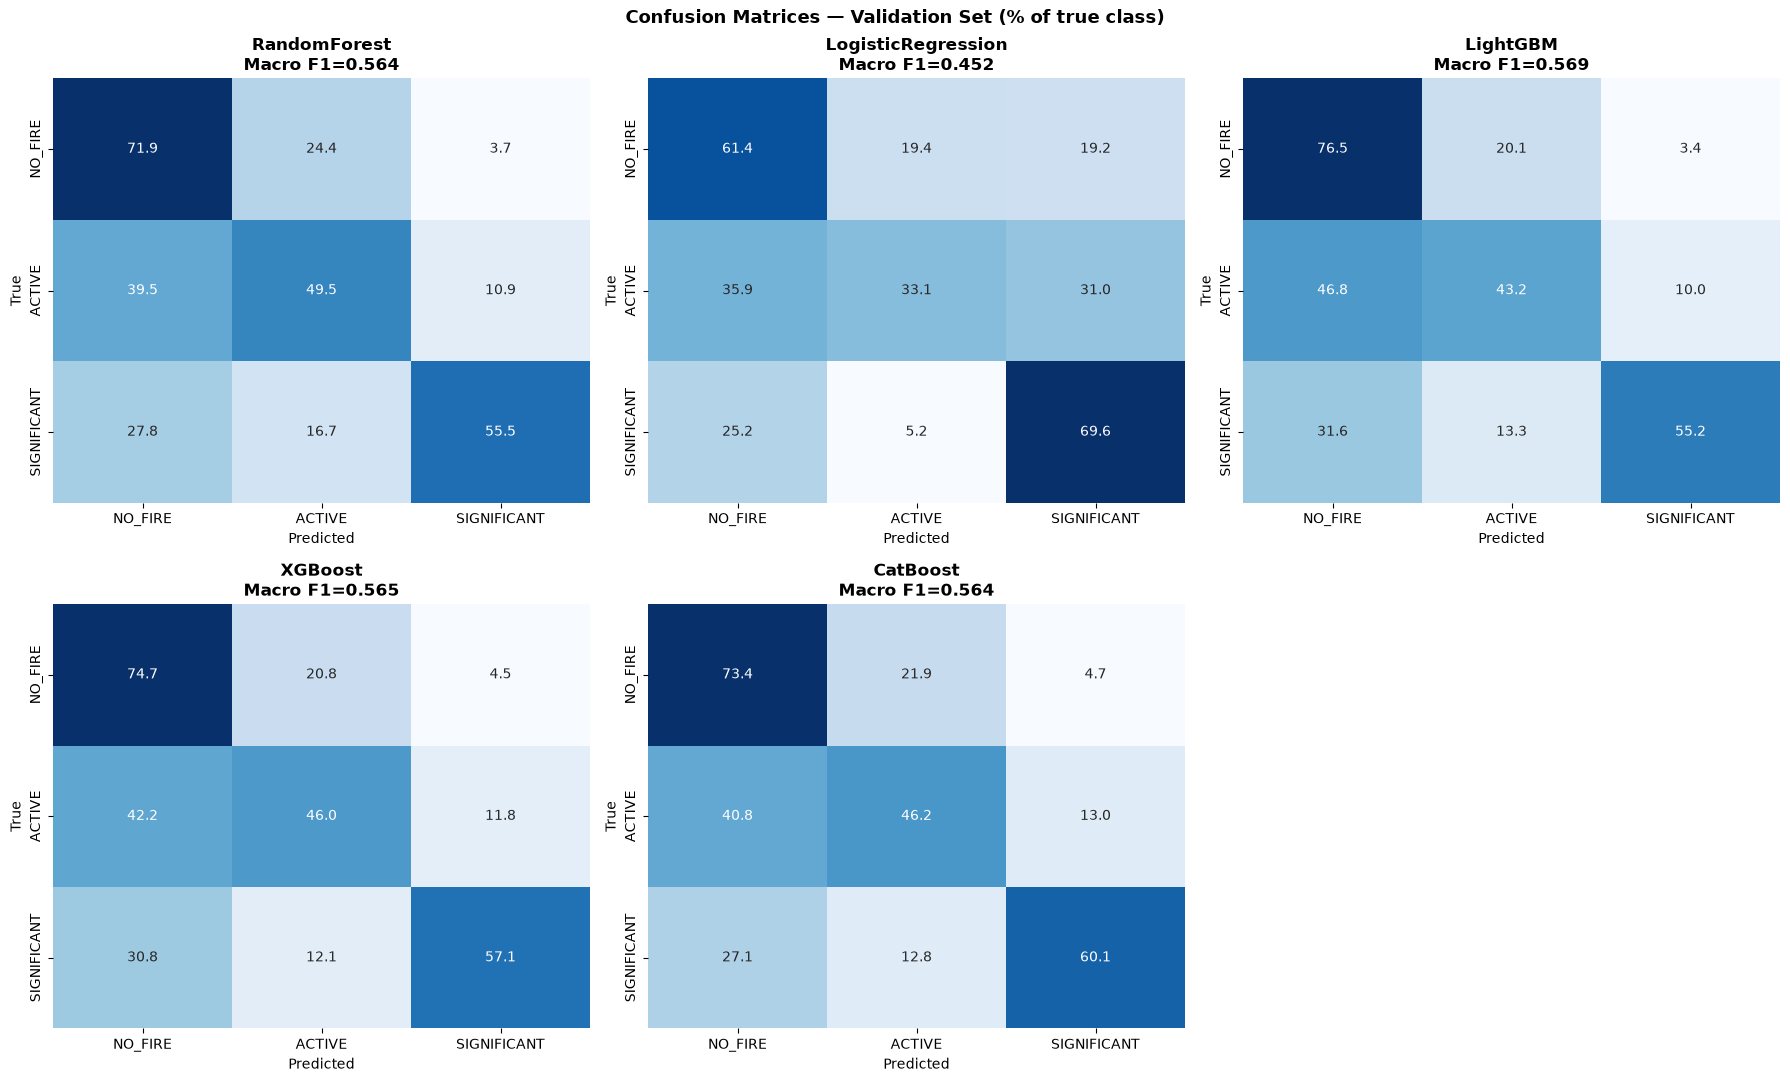

In [19]:
# ── CELL 11: Confusion matrices for all models ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

model_preds = {}
for name, model in models.items():
    if name == "LogisticRegression":
        proba = model.predict_proba(X_val_sc)
        pred  = model.predict(X_val_sc)
    elif name == "LightGBM":
        proba = model.predict(X_val)
        pred  = np.argmax(proba, axis=1)
    elif name == "CatBoost":
        pred  = model.predict(X_val).flatten()
    else:
        pred  = model.predict(X_val)
    model_preds[name] = pred

for ax, (name, pred) in zip(axes, model_preds.items()):
    cm  = confusion_matrix(y_val, pred)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=RISK_LABELS, yticklabels=RISK_LABELS,
                ax=ax, cbar=False)
    macro_f1 = f1_score(y_val, pred, average="macro")
    ax.set_title(f"{name}\nMacro F1={macro_f1:.3f}", fontweight="bold")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Confusion Matrices — Validation Set (% of true class)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

In [20]:
# ── CELL 12: Pick winner & save all models ────────────────────────
# Winner = highest val Macro AUC
winner_name = (results_df[results_df["split"] == "val"]
               .sort_values("macro_auc", ascending=False)
               .iloc[0]["model"])

print(f"Winner: {winner_name}")
print(f"\nVal results:")
print(val_results[["model","macro_f1","macro_auc"]].to_string(index=False))

# Save all models
for name, model in models.items():
    if name == "LightGBM":
        model.save_model(str(OUT_DIR / f"{name}.txt"))
    else:
        joblib.dump(model, OUT_DIR / f"{name}.pkl")
    print(f"✓ Saved {name}")

# Save scaler (needed for LogisticRegression at inference)
joblib.dump(scaler, OUT_DIR / "scaler.pkl")

import json
summary = {
    "winner":   winner_name,
    "features": FEATURES,
    "splits": {
        "train_years": list(range(2015, 2024)),
        "val_year":    2023,
        "test_year":   2025,
    },
    "val_results":  val_results[["model","macro_f1","macro_auc"]].to_dict("records"),
    "test_results": test_results[["model","macro_f1","macro_auc"]].to_dict("records"),
}
with open(OUT_DIR / "comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Summary saved → {OUT_DIR / 'comparison_summary.json'}")
print(f"\n→ Proceed to 05_final_model_xai.ipynb with: {winner_name}")

Winner: CatBoost

Val results:
             model  macro_f1  macro_auc
          CatBoost    0.5642     0.7608
           XGBoost    0.5653     0.7540
          LightGBM    0.5685     0.7527
      RandomForest    0.5638     0.7454
LogisticRegression    0.4519     0.7157
✓ Saved RandomForest
✓ Saved LogisticRegression
✓ Saved LightGBM
✓ Saved XGBoost
✓ Saved CatBoost

✓ Summary saved → outputs/model_comparison/comparison_summary.json

→ Proceed to 05_final_model_xai.ipynb with: CatBoost
